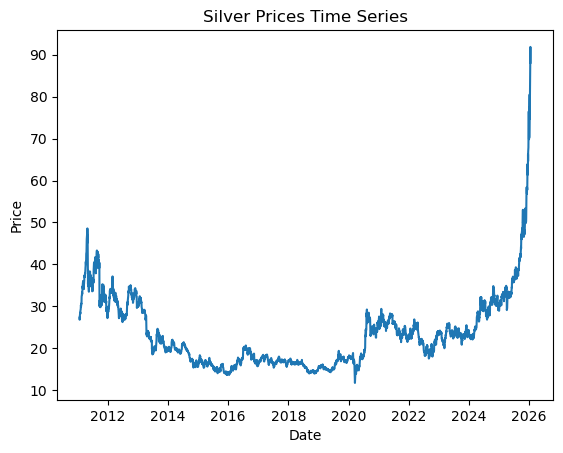

ADF Statistic: 3.1461628433740447
p-value: 1.0
Critical Values:
	1%: -3.4321006143182444
	5%: -2.8623135247610696
	10%: -2.5671817580180245


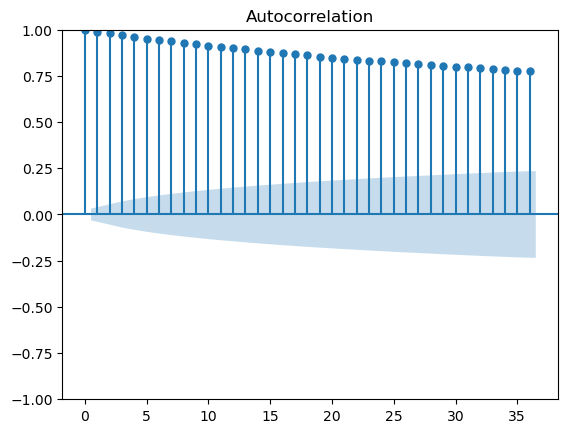

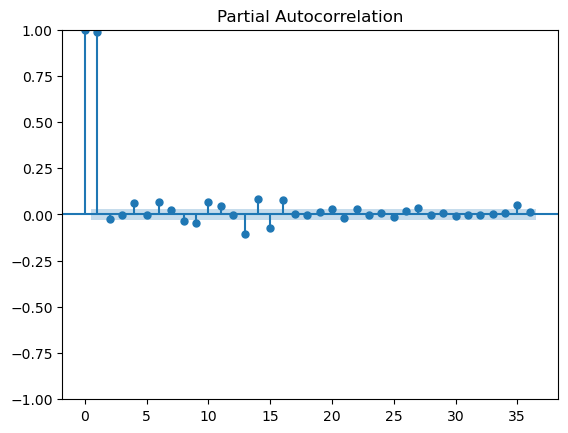

RMSE: 13.369209809196422


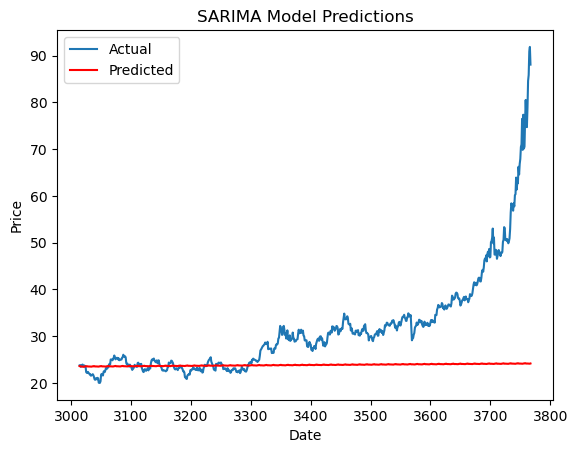

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
data = pd.read_csv('silver_prices_data.csv')
data['Date'] = pd.to_datetime(data['Date'])
plt.plot(data['Date'], data['Price'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Silver Prices Time Series')
plt.show()
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))
check_stationarity(data['Price'])
plot_acf(data['Price'])
plt.show()
plot_pacf(data['Price'])
plt.show()
sarima_model = SARIMAX(data['Price'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit()
train_size = int(len(data) * 0.8)
train, test = data['Price'][:train_size], data['Price'][train_size:]
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima_model.fit()
predictions = sarima_result.predict(start=len(train), end=len(train) + len(test) - 1 )
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
print('RMSE:', rmse)
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, color='red', label='Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('SARIMA Model Predictions')
plt.legend()

plt.show()